In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("DataScaling").getOrCreate()

# Load your dataset
df = spark.read.csv(
    "/Users/jaswanthravipati/Documents/Flights_Project/flights.csv",
    header=True,
    inferSchema=True
)

sizes = [1, 5, 10, 50, 100]

for m in sizes:
    print(f"Creating {m}x dataset...")

    df_big = df
    for _ in range(m - 1):
        df_big = df_big.union(df)

    df_big.write.csv(
        f"/Users/jaswanthravipati/Documents/Flights_Project/flights_{m}x",
        header=True,
        mode="overwrite"
    )

print("Datasets created")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/26 16:28:39 WARN Utils: Your hostname, Jaswanths-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.21.47.143 instead (on interface en0)
26/04/26 16:28:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 16:28:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/26 16:28:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Creating 1x dataset...


Creating 5x dataset...


Creating 10x dataset...


Creating 50x dataset...


Creating 100x dataset...


Datasets created


In [2]:
import pandas as pd
import time
import glob

sizes = [1, 5, 10, 50, 100]
pandas_results = {}

for m in sizes:
    print(f"\nPandas processing {m}x dataset")

    start = time.time()

    # Get all part files
    files = glob.glob(
        f"/Users/jaswanthravipati/Documents/Flights_Project/flights_{m}x/*.csv"
    )

    # Read and combine
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    df = df.dropna(subset=["ARR_DELAY"])

    result = df.groupby("ORIGIN").agg({
        "ARR_DELAY": "mean",
        "ORIGIN": "count"
    }).rename(columns={"ARR_DELAY": "avg_delay", "ORIGIN": "total_flights"})

    pandas_t = time.time() - start
    pandas_results[m] = pandas_t

    print("Pandas Time:", pandas_t)
    print(result.head())


Pandas processing 1x dataset
Pandas Time: 0.674677848815918
        avg_delay  total_flights
ORIGIN                          
ABE     21.815242            433
ABI      4.560811            148
ABQ      1.750465           2152
ABR     29.894737             57
ABY     13.512821             78

Pandas processing 5x dataset
Pandas Time: 3.1232047080993652
        avg_delay  total_flights
ORIGIN                          
ABE     21.815242           2165
ABI      4.560811            740
ABQ      1.750465          10760
ABR     29.894737            285
ABY     13.512821            390

Pandas processing 10x dataset
Pandas Time: 6.491034746170044
        avg_delay  total_flights
ORIGIN                          
ABE     21.815242           4330
ABI      4.560811           1480
ABQ      1.750465          21520
ABR     29.894737            570
ABY     13.512821            780

Pandas processing 50x dataset
Pandas Time: 36.791210889816284
        avg_delay  total_flights
ORIGIN                    

In [3]:
from pyspark.sql.functions import avg, count

spark_results = {}

for m in sizes:
    print(f"\nSpark processing {m}x dataset")

    start = time.time()

    df = spark.read.csv(
        f"/Users/jaswanthravipati/Documents/Flights_Project/flights_{m}x",
        header=True,
        inferSchema=True
    )

    df = df.dropna(subset=["ARR_DELAY"])

    result = df.groupBy("ORIGIN").agg(
        avg("ARR_DELAY").alias("avg_delay"),
        count("*").alias("total_flights")
    )

    result.show(5)

    spark_t = time.time() - start

    spark_results[m] = spark_t

    print("Spark Time:", spark_t)


Spark processing 1x dataset
+------+------------------+-------------+
|ORIGIN|         avg_delay|total_flights|
+------+------------------+-------------+
|   DLG|10.038461538461538|           26|
|   MSY| 8.745516238487639|         4126|
|   GEG|0.6768257619321449|         1739|
|   BUR| 4.609154929577465|         2556|
|   SNA| 7.065013054830287|         3830|
+------+------------------+-------------+
only showing top 5 rows
Spark Time: 3.175396203994751

Spark processing 5x dataset


+------+------------------+-------------+
|ORIGIN|         avg_delay|total_flights|
+------+------------------+-------------+
|   DLG|10.038461538461538|          130|
|   MSY| 8.745516238487639|        20630|
|   GEG|0.6768257619321449|         8695|
|   BUR| 4.609154929577465|        12780|
|   SNA| 7.065013054830287|        19150|
+------+------------------+-------------+
only showing top 5 rows
Spark Time: 1.7132539749145508

Spark processing 10x dataset


+------+------------------+-------------+
|ORIGIN|         avg_delay|total_flights|
+------+------------------+-------------+
|   DLG|10.038461538461538|          260|
|   MSY| 8.745516238487639|        41260|
|   GEG|0.6768257619321449|        17390|
|   BUR| 4.609154929577465|        25560|
|   SNA| 7.065013054830287|        38300|
+------+------------------+-------------+
only showing top 5 rows
Spark Time: 3.9331610202789307

Spark processing 50x dataset


+------+------------------+-------------+
|ORIGIN|         avg_delay|total_flights|
+------+------------------+-------------+
|   DLG|10.038461538461538|         1300|
|   MSY| 8.745516238487639|       206300|
|   GEG|0.6768257619321449|        86950|
|   BUR| 4.609154929577465|       127800|
|   SNA| 7.065013054830287|       191500|
+------+------------------+-------------+
only showing top 5 rows
Spark Time: 16.452783823013306

Spark processing 100x dataset


[Stage 33:===================================================>  (103 + 6) / 109]

+------+------------------+-------------+
|ORIGIN|         avg_delay|total_flights|
+------+------------------+-------------+
|   DLG|10.038461538461538|         2600|
|   MSY| 8.745516238487639|       412600|
|   GEG|0.6768257619321449|       173900|
|   BUR| 4.609154929577465|       255600|
|   SNA| 7.065013054830287|       383000|
+------+------------------+-------------+
only showing top 5 rows
Spark Time: 34.075860023498535


In [4]:
comparison = pd.DataFrame({
    "Size (x)": sizes,
    "Pandas Time": [pandas_results[m] for m in sizes],
    "Spark Time": [spark_results[m] for m in sizes]
})

comparison

,Size (x),Pandas Time,Spark Time
0,1,0.674678,3.175396
1,5,3.123205,1.713254
2,10,6.491035,3.933161
3,50,36.791211,16.452784
4,100,77.491798,34.075860


In [5]:
df = spark.read.csv(
    "/Users/jaswanthravipati/Documents/Flights_Project/flights.csv",
    header=True,
    inferSchema=True
)

df.limit(5).toPandas()

,YEAR,MONTH,MKT_UNIQUE_CARRIER,BRANDED_CODE_SHARE,MKT_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,...,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,CANCELLED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2025,12,AA,AA,1,12478,1247805,31703,JFK,"New York, NY",...,649,-11.0,959,-22.0,0.0,NaN,NaN,NaN,NaN,NaN
1,2025,12,AA,AA,1,12478,1247805,31703,JFK,"New York, NY",...,649,-11.0,1006,-15.0,0.0,NaN,NaN,NaN,NaN,NaN
2,2025,12,AA,AA,1,12478,1247805,31703,JFK,"New York, NY",...,652,-8.0,956,-25.0,0.0,NaN,NaN,NaN,NaN,NaN
3,2025,12,AA,AA,1,12478,1247805,31703,JFK,"New York, NY",...,652,-8.0,1034,-1.0,0.0,NaN,NaN,NaN,NaN,NaN
4,2025,12,AA,AA,1,12478,1247805,31703,JFK,"New York, NY",...,652,-7.0,1041,15.0,0.0,0.0,0.0,15.0,0.0,0.0


In [6]:
print("Shape:", (df.count(), len(df.columns)))
print("\nColumns:\n", df.columns)
print("\nData Types:")
df.printSchema()

Shape: (644987, 29)

Columns:
 ['YEAR', 'MONTH', 'MKT_UNIQUE_CARRIER', 'BRANDED_CODE_SHARE', 'MKT_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEST_STATE_NM', 'DEP_TIME', 'DEP_DELAY', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

Data Types:
root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- MKT_UNIQUE_CARRIER: string (nullable = true)
 |-- BRANDED_CODE_SHARE: string (nullable = true)
 |-- MKT_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN_AIRPORT_ID: integer (nullable = true)
 |-- ORIGIN_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- ORIGIN_CITY_MARKET_ID: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- ORIGIN_CITY_NAME: strin

In [7]:
from pyspark.sql.functions import col, sum as spark_sum, lit, round
total_rows = df.count()

missing_wide = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

expr = "stack({0}, {1}) as (column_name, missing_count)".format(
    len(df.columns),
    ", ".join([f"'{c}', `{c}`" for c in df.columns])
)

missing_long = missing_wide.selectExpr(expr)

missing_final = missing_long.withColumn(
    "missing %",
    round((col("missing_count") / lit(total_rows)) * 100, 2)
)

missing_final.orderBy(col("missing %").desc()).show(truncate=False)

+---------------------+-------------+---------+
|column_name          |missing_count|missing %|
+---------------------+-------------+---------+
|CARRIER_DELAY        |474854       |73.62    |
|WEATHER_DELAY        |474854       |73.62    |
|NAS_DELAY            |474854       |73.62    |
|SECURITY_DELAY       |474854       |73.62    |
|LATE_AIRCRAFT_DELAY  |474854       |73.62    |
|ARR_DELAY            |12117        |1.88     |
|ARR_TIME             |10766        |1.67     |
|DEP_DELAY            |10119        |1.57     |
|DEP_TIME             |10062        |1.56     |
|YEAR                 |0            |0.0      |
|MONTH                |0            |0.0      |
|MKT_UNIQUE_CARRIER   |0            |0.0      |
|BRANDED_CODE_SHARE   |0            |0.0      |
|MKT_CARRIER_FL_NUM   |0            |0.0      |
|ORIGIN_AIRPORT_ID    |0            |0.0      |
|ORIGIN_AIRPORT_SEQ_ID|0            |0.0      |
|ORIGIN_CITY_MARKET_ID|0            |0.0      |
|ORIGIN               |0            |0.0

In [8]:
df_clean = df.dropna(subset=["ARR_DELAY"])

rows = df_clean.count()
cols = len(df_clean.columns)

print(f"After removing null ARR_DELAY: ({rows}, {cols})")

After removing null ARR_DELAY: (632870, 29)


In [9]:
from pyspark.sql.functions import col, sum as spark_sum, lit, round

total_rows = df_clean.count()

missing_wide = df_clean.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df_clean.columns
])

expr = "stack({0}, {1}) as (column_name, missing_count)".format(
    len(df_clean.columns),
    ", ".join([f"'{c}', `{c}`" for c in df_clean.columns])
)

missing_long = missing_wide.selectExpr(expr)

missing_final = missing_long.withColumn(
    "missing %",
    round((col("missing_count") / lit(total_rows)) * 100, 2)
)

missing_final.orderBy(col("missing %").desc()).show(truncate=False)

+---------------------+-------------+---------+
|column_name          |missing_count|missing %|
+---------------------+-------------+---------+
|CARRIER_DELAY        |462737       |73.12    |
|WEATHER_DELAY        |462737       |73.12    |
|NAS_DELAY            |462737       |73.12    |
|SECURITY_DELAY       |462737       |73.12    |
|LATE_AIRCRAFT_DELAY  |462737       |73.12    |
|YEAR                 |0            |0.0      |
|MONTH                |0            |0.0      |
|MKT_UNIQUE_CARRIER   |0            |0.0      |
|BRANDED_CODE_SHARE   |0            |0.0      |
|MKT_CARRIER_FL_NUM   |0            |0.0      |
|ORIGIN_AIRPORT_ID    |0            |0.0      |
|ORIGIN_AIRPORT_SEQ_ID|0            |0.0      |
|ORIGIN_CITY_MARKET_ID|0            |0.0      |
|ORIGIN               |0            |0.0      |
|ORIGIN_CITY_NAME     |0            |0.0      |
|ORIGIN_STATE_ABR     |0            |0.0      |
|ORIGIN_STATE_NM      |0            |0.0      |
|DEST_AIRPORT_ID      |0            |0.0

In [10]:
df_clean.select("ARR_DELAY", "DEP_DELAY").describe().show()

+-------+------------------+-----------------+
|summary|         ARR_DELAY|        DEP_DELAY|
+-------+------------------+-----------------+
|  count|            632870|           632870|
|   mean|13.452603220250605|18.53572297628265|
| stddev| 68.05290081295546|65.33999421327387|
|    min|             -97.0|           -115.0|
|    max|            2846.0|           2868.0|
+-------+------------------+-----------------+



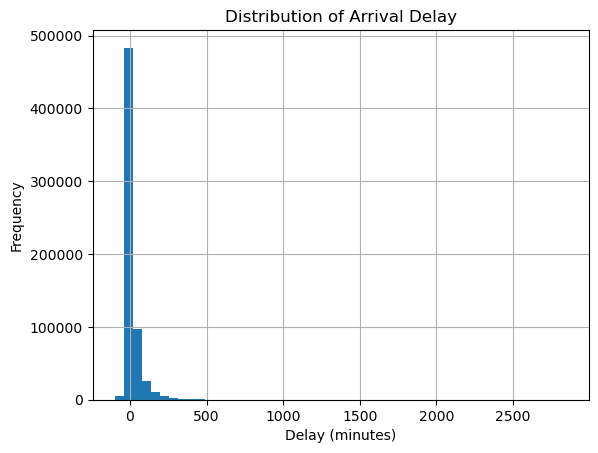

In [11]:
import matplotlib.pyplot as plt

arr_delay_pd = df_clean.select("ARR_DELAY").toPandas()

arr_delay_pd["ARR_DELAY"].hist(bins=50)

plt.title("Distribution of Arrival Delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

In [12]:
from pyspark.sql.functions import count, col

df_clean.groupBy("ORIGIN") \
    .agg(count("*").alias("total_flights")) \
    .orderBy(col("total_flights").desc()) \
    .show(10)

+------+-------------+
|ORIGIN|total_flights|
+------+-------------+
|   ORD|        29028|
|   ATL|        28344|
|   DEN|        25775|
|   DFW|        25542|
|   CLT|        19324|
|   PHX|        17679|
|   LAX|        16404|
|   LAS|        14679|
|   IAH|        14421|
|   SEA|        14352|
+------+-------------+
only showing top 10 rows
